# 03: IPS And SNIPS Policy Evaluation

This is the first off-policy evaluation notebook that actually estimates counterfactual policy values.

Notebook 1 established that Open Bandit has logged actions, rewards, context, and propensities. Notebook 2 studied the behavior policy and showed why the `random/men` slice is the cleanest starting point. Notebook 3 now asks:

> Given logged data from a behavior policy, what would the click rate have been under a different recommendation policy?

We will estimate that value using two classic off-policy evaluation estimators:

- **IPS**, or inverse propensity scoring
- **SNIPS**, or self-normalized inverse propensity scoring

The notebook uses simple evaluation policies on purpose. The goal is to make the mechanics of OPE clear before introducing reward models and doubly robust estimation in the next notebook.


<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook introduces IPS and self-normalized IPS, using the random logging policy to show how importance weighting changes policy-value estimates.

<!-- mathematical-setup -->

## Mathematical Setup

Inverse propensity scoring estimates target-policy value by reweighting logged rewards:

$$
\widehat V_{\text{IPS}}(\pi)=\frac{1}{n}\sum_{i=1}^n
\frac{\pi(A_i\mid X_i)}{b(A_i\mid X_i)}R_i.
$$

Self-normalized IPS trades a small amount of bias for lower variance:

$$
\widehat V_{\text{SNIPS}}(\pi)=
\frac{\sum_{i=1}^n w_i(\pi)R_i}{\sum_{i=1}^n w_i(\pi)}.
$$

Both estimators depend on overlap. When a policy puts weight on actions that are rare in the logs, a few observations can dominate the estimate.


## Estimator Framing

For each logged recommendation event, we observe:

- `X`: context available before recommendation
- `A`: logged action, here the shown `item_id`
- `Y`: reward, here `click`
- `pi_b(A|X)`: behavior-policy probability for the logged action, stored as `propensity_score`

For an evaluation policy `pi_e`, IPS estimates its value with:

`V_IPS(pi_e) = mean((pi_e(A|X) / pi_b(A|X)) * Y)`

The ratio `pi_e(A|X) / pi_b(A|X)` is the importance weight. It converts rewards collected under the behavior policy into an estimate of rewards under the evaluation policy.

SNIPS uses the same weights, but normalizes by their sum:

`V_SNIPS(pi_e) = sum(w_i * Y_i) / sum(w_i)`

IPS is unbiased under standard assumptions when propensities are correct and support holds, but it can have high variance. SNIPS is usually biased in finite samples, but often more stable because it forces the average weight to behave like 1.


#### Setup

This cell imports the libraries used for policy construction, estimation, diagnostics, and plotting.

The notebook intentionally uses plain `pandas` and `numpy` functions so the estimator formulas stay transparent.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")


This cell prepares the notebook environment for IPS and SNIPS off-policy evaluation. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Locate Processed Open Bandit Samples

This cell finds the repository root and defines the cached sample paths produced by the earlier notebooks.

The main estimation work uses `open_bandit_random_men_sample.parquet`. We also load `open_bandit_bts_men_sample.parquet` later to show how the same candidate policies behave when evaluated from adaptive BTS logs.


In [2]:
RANDOM_SAMPLE_RELATIVE_PATH = Path("data/processed/open_bandit_random_men_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / RANDOM_SAMPLE_RELATIVE_PATH).exists()
)

RANDOM_SAMPLE_PATH = PROJECT_ROOT / RANDOM_SAMPLE_RELATIVE_PATH
BTS_SAMPLE_PATH = PROJECT_ROOT / "data/processed/open_bandit_bts_men_sample.parquet"

pd.DataFrame(
    {
        "path_name": ["project_root", "random_sample", "bts_sample"],
        "path": [PROJECT_ROOT, RANDOM_SAMPLE_PATH, BTS_SAMPLE_PATH],
        "exists": [PROJECT_ROOT.exists(), RANDOM_SAMPLE_PATH.exists(), BTS_SAMPLE_PATH.exists()],
    }
)


The printed paths are a reproducibility checkpoint. Once the notebook can find the cached data, the rest of the analysis can run without manual path edits.


#### Load The Random Behavior-Policy Log

This cell loads the random-policy sample that Notebook 1 cached. It then sorts by timestamp.

Sorting by time lets us create a simple train/evaluation split that mimics a realistic workflow: use earlier logged data to design a candidate policy, then estimate that policy's value on later held-out logged data. This avoids learning and evaluating a policy on the exact same rows.


In [3]:
random_df = pd.read_parquet(RANDOM_SAMPLE_PATH).sort_values("timestamp").reset_index(drop=True)

random_df[["timestamp", "item_id", "position", "click", "propensity_score"]].head()


,timestamp,item_id,position,click,propensity_score
0,2019-11-24 00:00:03.800821+00:00,0,1,0,0.029412
1,2019-11-24 00:00:03.801019+00:00,25,3,0,0.029412
2,2019-11-24 00:00:03.801099+00:00,23,2,0,0.029412
3,2019-11-24 00:00:17.634355+00:00,25,1,0,0.029412
4,2019-11-24 00:00:17.634998+00:00,30,2,0,0.029412


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


### Time-Based Train and Evaluation Split

This cell splits the random-policy sample into two halves:

- `train_df`: used to define simple evaluation policies
- `eval_df`: used to estimate policy values with IPS and SNIPS

This is important because a policy that is tuned on the same rewards used for OPE can look artificially good. The split keeps the policy-design step separate from the policy-evaluation step.


In [4]:
SPLIT_FRACTION = 0.50
split_idx = int(len(random_df) * SPLIT_FRACTION)

train_df = random_df.iloc[:split_idx].copy()
eval_df = random_df.iloc[split_idx:].copy()

time_split_summary = pd.DataFrame(
    {
        "split": ["train", "evaluation"],
        "rows": [len(train_df), len(eval_df)],
        "min_timestamp": [train_df["timestamp"].min(), eval_df["timestamp"].min()],
        "max_timestamp": [train_df["timestamp"].max(), eval_df["timestamp"].max()],
        "observed_click_rate": [train_df["click"].mean(), eval_df["click"].mean()],
    }
)

time_split_summary


,split,rows,min_timestamp,max_timestamp,observed_click_rate
0,train,100000,2019-11-24 00:00:03.800821+00:00,2019-11-25 10:01:18.392921+00:00,0.005400
1,evaluation,100000,2019-11-25 10:01:18.393450+00:00,2019-11-27 02:50:16.027289+00:00,0.004980


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


#### Define The Action Space

The action space is the set of items that a policy may recommend. For this notebook, we use the items observed in the random-policy sample.

Using a fixed action space makes policy probabilities easy to audit. Every candidate policy must assign nonnegative probabilities that sum to 1 across these items. This is also where support matters. If an evaluation policy assigns probability to an item that never appears in the logged data, IPS cannot evaluate it.


In [5]:
action_space = np.array(sorted(random_df["item_id"].unique()))
n_actions = len(action_space)

action_space_summary = pd.Series(
    {
        "n_actions": n_actions,
        "min_item_id": action_space.min(),
        "max_item_id": action_space.max(),
        "train_unique_items": train_df["item_id"].nunique(),
        "eval_unique_items": eval_df["item_id"].nunique(),
    }
).to_frame("value")

action_space_summary


,value
n_actions,34
min_item_id,0
max_item_id,33
train_unique_items,34
eval_unique_items,34


The action-space definition fixes the set of items that evaluation policies are allowed to choose. OPE estimates are only meaningful for policies whose action probabilities live inside this logged support.


#### Estimate Item Statistics On The Train Split

This cell computes item-level exposure and click statistics using only the training rows.

The raw item click rate can be noisy because clicks are sparse. We therefore create a smoothed click rate using a simple empirical-Bayes style formula:

`smoothed_ctr = (item_clicks + alpha * global_ctr) / (item_impressions + alpha)`

The smoothing constant `alpha` shrinks low-exposure items toward the global click rate so a tiny number of lucky clicks has limited influence on the policy.


In [6]:
SMOOTHING_ALPHA = 50
train_global_ctr = train_df["click"].mean()

item_stats = (
    train_df.groupby("item_id")
    .agg(train_impressions=("click", "size"), train_clicks=("click", "sum"), train_ctr=("click", "mean"))
    .reindex(action_space, fill_value=0)
    .rename_axis("item_id")
    .reset_index()
)
item_stats["smoothed_ctr"] = (
    item_stats["train_clicks"] + SMOOTHING_ALPHA * train_global_ctr
) / (item_stats["train_impressions"] + SMOOTHING_ALPHA)
item_stats["train_exposure_share"] = item_stats["train_impressions"] / item_stats["train_impressions"].sum()

item_stats.sort_values("smoothed_ctr", ascending=False).head(10)


,item_id,train_impressions,train_clicks,train_ctr,smoothed_ctr,train_exposure_share
31,31,2581,39,0.015110,0.014926,0.025810
27,27,3029,35,0.011555,0.011455,0.030290
23,23,2602,26,0.009992,0.009906,0.026020
14,14,2800,24,0.008571,0.008516,0.028000
21,21,3039,25,0.008226,0.008181,0.030390
0,0,2920,22,0.007534,0.007498,0.029200
22,22,3330,25,0.007508,0.007476,0.033300
20,20,2867,20,0.006976,0.006949,0.028670
12,12,2902,20,0.006892,0.006867,0.029020
2,2,3207,22,0.006860,0.006838,0.032070


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


#### Plot Training Item Quality Signals

This plot shows the smoothed training click rates for the top items. It is a policy-construction step before OPE. It is only the signal used to build candidate evaluation policies.

A realistic recommender policy would usually be context-aware. Here we start with context-free item policies because they make IPS and SNIPS easy to inspect. Later notebooks can add reward models and context-aware policies.


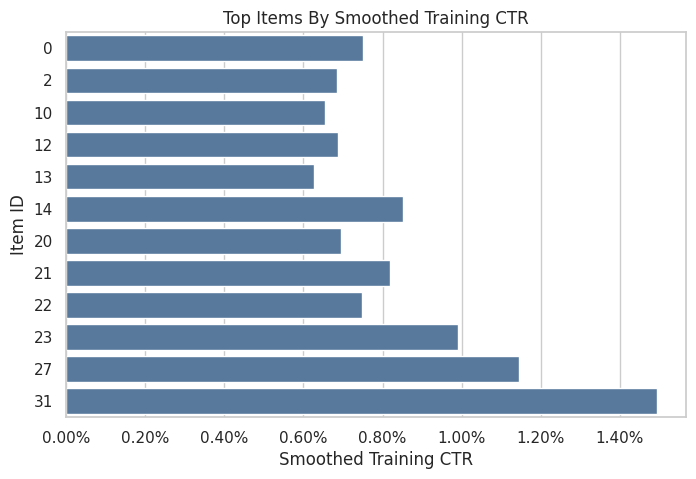

In [7]:
top_items = item_stats.sort_values("smoothed_ctr", ascending=False).head(12).sort_values("smoothed_ctr")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_items, x="smoothed_ctr", y="item_id", orient="h", ax=ax, color="#4C78A8")
ax.set_title("Top Items By Smoothed Training CTR")
ax.set_xlabel("Smoothed Training CTR")
ax.set_ylabel("Item ID")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()


The item statistics estimate simple quality signals from the training split. These signals define benchmark evaluation policies while keeping the held-out evaluation log untouched. The figure should be read for the pattern and its decision consequence.


### Define Evaluation Policies

This cell defines four simple candidate policies:

- `uniform`: recommends every item with equal probability
- `exposure_popularity`: recommends items in proportion to their training exposure share
- `ctr_weighted`: recommends items in proportion to smoothed training CTR
- `epsilon_greedy_top_ctr`: assigns most probability to the top smoothed-CTR item, while keeping exploration probability on all items

These policies are intentionally simple. They create clear differences in probability distributions, which makes IPS and SNIPS diagnostics easier to understand.


In [8]:
# Define simple evaluation policies.
def normalize_probabilities(values):
    """
    Normalize nonnegative scores into action probabilities.
    
    Idea
    ----
    The helper turns item scores into a valid evaluation-policy distribution and protects OPE estimators from zero-sum or invalid probability vectors.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    numpy.ndarray
        Probability vector that sums to one.
    """
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, None)
    total = values.sum()
    if total <= 0:
        raise ValueError("Policy scores must have positive total mass.")
    return values / total

uniform_probs = np.full(n_actions, 1 / n_actions)
exposure_popularity_probs = normalize_probabilities(item_stats["train_exposure_share"].to_numpy())
ctr_weighted_probs = normalize_probabilities(item_stats["smoothed_ctr"].to_numpy())

epsilon = 0.15
epsilon_greedy_probs = np.full(n_actions, epsilon / n_actions)
top_ctr_index = int(item_stats["smoothed_ctr"].to_numpy().argmax())
epsilon_greedy_probs[top_ctr_index] += 1 - epsilon

policy_probability_df = pd.DataFrame(
    {
        "item_id": action_space,
        "uniform": uniform_probs,
        "exposure_popularity": exposure_popularity_probs,
        "ctr_weighted": ctr_weighted_probs,
        "epsilon_greedy_top_ctr": epsilon_greedy_probs,
        "smoothed_ctr": item_stats["smoothed_ctr"],
        "train_exposure_share": item_stats["train_exposure_share"],
    }
)

policy_probability_df.head()


,item_id,uniform,exposure_popularity,ctr_weighted,epsilon_greedy_top_ctr,smoothed_ctr,train_exposure_share
0,0,0.029412,0.029200,0.040498,0.004412,0.007498,0.029200
1,1,0.029412,0.027590,0.025514,0.004412,0.004724,0.027590
2,2,0.029412,0.032070,0.036929,0.004412,0.006838,0.032070
3,3,0.029412,0.029650,0.020188,0.004412,0.003738,0.029650
4,4,0.029412,0.028410,0.017318,0.004412,0.003207,0.028410


The policy definitions create several offline candidates with different levels of targeting. Comparing simple policies first makes it easier to understand IPS, SNIPS, and DR behavior before moving to contextual policies.


#### Audit Policy Probability Mass

Every evaluation policy must assign a valid probability distribution over the action space. This cell checks that each policy sums to 1, has no negative probabilities, and gives every action at least some support.

The positive-support check is useful because deterministic policies can create brittle OPE. If a policy assigns zero probability to most actions, the estimate may depend on a very small subset of logged rows.


In [9]:
policy_cols = ["uniform", "exposure_popularity", "ctr_weighted", "epsilon_greedy_top_ctr"]

policy_audit = pd.DataFrame(
    [
        {
            "policy": policy,
            "probability_sum": policy_probability_df[policy].sum(),
            "min_probability": policy_probability_df[policy].min(),
            "max_probability": policy_probability_df[policy].max(),
            "actions_with_positive_probability": int((policy_probability_df[policy] > 0).sum()),
        }
        for policy in policy_cols
    ]
)

policy_audit


,policy,probability_sum,min_probability,max_probability,actions_with_positive_probability
0,uniform,1.000000,0.029412,0.029412,34
1,exposure_popularity,1.000000,0.025810,0.033300,34
2,ctr_weighted,1.000000,0.009558,0.080613,34
3,epsilon_greedy_top_ctr,1.000000,0.004412,0.854412,34


The policy audit verifies that each evaluation policy assigns valid probability mass over the action space. This is a basic but important check: OPE formulas assume probabilities sum to one and remain nonnegative.


#### Plot Evaluation Policy Distributions

This plot shows how each candidate policy distributes probability across items. The items are ordered by smoothed training CTR.

The uniform and exposure-popularity policies should be relatively flat. The CTR-weighted policy should tilt toward better training items. The epsilon-greedy policy should be intentionally concentrated on the top item while preserving some exploration.


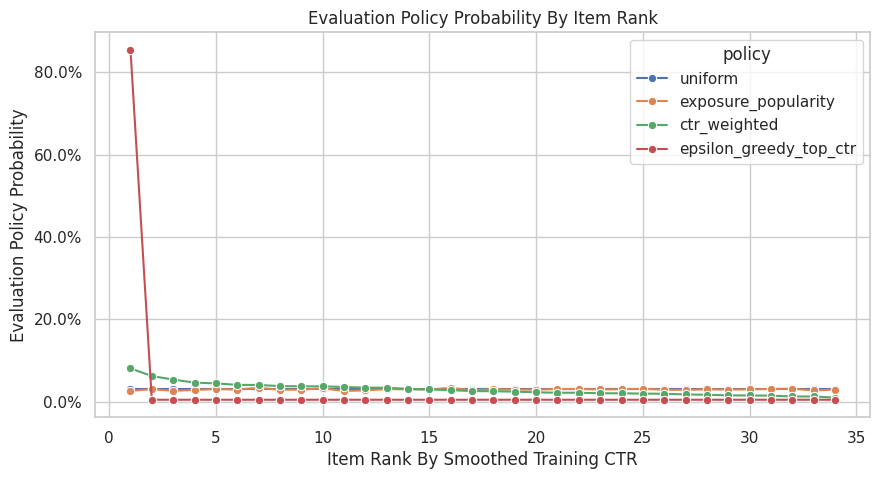

In [10]:
policy_plot_df = (
    policy_probability_df.sort_values("smoothed_ctr", ascending=False)
    .assign(action_rank=lambda x: np.arange(1, len(x) + 1))
    .melt(
        id_vars=["item_id", "action_rank", "smoothed_ctr"],
        value_vars=policy_cols,
        var_name="policy",
        value_name="probability",
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=policy_plot_df, x="action_rank", y="probability", hue="policy", marker="o", ax=ax)
ax.set_title("Evaluation Policy Probability By Item Rank")
ax.set_xlabel("Item Rank By Smoothed Training CTR")
ax.set_ylabel("Evaluation Policy Probability")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.show()


The policy distribution plot shows how concentrated each candidate policy is. More concentrated policies can have higher expected reward, but they usually create larger importance weights and higher variance.


#### Attach Evaluation Policy Probabilities To Logged Rows

IPS needs `pi_e(A|X)`, the evaluation-policy probability of the action that was actually logged. Since our policies are context-free item policies, this means mapping each logged `item_id` to its policy probability.

The behavior-policy probability `pi_b(A|X)` is already in the data as `propensity_score`. The importance weight is `pi_e / pi_b`.


In [11]:
eval_scored = eval_df[["timestamp", "item_id", "position", "click", "propensity_score"]].copy()

for policy in policy_cols:
    probability_map = policy_probability_df.set_index("item_id")[policy]
    eval_scored[f"pi_e_{policy}"] = eval_scored["item_id"].map(probability_map)
    eval_scored[f"w_{policy}"] = eval_scored[f"pi_e_{policy}"] / eval_scored["propensity_score"]

missing_policy_probability = eval_scored[[f"pi_e_{policy}" for policy in policy_cols]].isna().sum()
missing_policy_probability


pi_e_uniform                   0
pi_e_exposure_popularity       0
pi_e_ctr_weighted              0
pi_e_epsilon_greedy_top_ctr    0
dtype: int64

Attaching evaluation-policy probabilities to logged rows creates the numerator of the importance weight. Once this is joined to the behavior propensity, IPS and SNIPS can estimate each policy's value.


#### Preview The Scored Evaluation Log

This cell shows the held-out logged rows after adding evaluation-policy probabilities and importance weights.

A row can have a different weight under each evaluation policy. If a policy likes the logged item more than the behavior policy did, the weight is above 1. If it likes the logged item less, the weight is below 1.


In [12]:
preview_cols = ["timestamp", "item_id", "position", "click", "propensity_score"]
for policy in policy_cols:
    preview_cols.extend([f"pi_e_{policy}", f"w_{policy}"])

eval_scored[preview_cols].head()


,timestamp,item_id,position,click,propensity_score,pi_e_uniform,w_uniform,pi_e_exposure_popularity,w_exposure_popularity,pi_e_ctr_weighted,w_ctr_weighted,pi_e_epsilon_greedy_top_ctr,w_epsilon_greedy_top_ctr
100000,2019-11-25 10:01:18.393450+00:00,22,2,0,0.029412,0.029412,1.000000,0.033300,1.132200,0.040379,1.372880,0.004412,0.150000
100001,2019-11-25 10:01:19.400109+00:00,22,2,0,0.029412,0.029412,1.000000,0.033300,1.132200,0.040379,1.372880,0.004412,0.150000
100002,2019-11-25 10:01:19.400113+00:00,10,3,0,0.029412,0.029412,1.000000,0.025860,0.879240,0.035384,1.203070,0.004412,0.150000
100003,2019-11-25 10:01:19.400175+00:00,25,1,0,0.029412,0.029412,1.000000,0.031250,1.062500,0.012367,0.420470,0.004412,0.150000
100004,2019-11-25 10:01:25.806862+00:00,0,1,0,0.029412,0.029412,1.000000,0.029200,0.992800,0.040498,1.376917,0.004412,0.150000


The scored-log preview confirms that each logged row now has behavior propensity, evaluation-policy probability, and reward information. This is the minimum row-level structure needed for IPS-family estimators.


#### Define IPS And SNIPS Helper Functions

This cell defines the estimator functions used throughout the notebook.

For IPS, the estimated value is the average of `weight * reward`. For SNIPS, the estimated value is the sum of weighted rewards divided by the sum of weights. The helper also computes an approximate standard error and 95% confidence interval.

For SNIPS, the standard error uses a common influence-function approximation, `w * (Y - V_SNIPS) / mean(w)`. It gives a useful and transparent diagnostic for this project.


In [13]:
# Define IPS and SNIPS helper functions.
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.square(weights).sum()


def estimate_ips_snips(reward, weight, policy_name, clip=None):
    """
    Estimate IPS and self-normalized IPS policy values.
    
    Idea
    ----
    The helper applies importance weights to logged rewards, optionally with clipping, so fixed or contextual policies can be compared under support diagnostics.
    
    Parameters
    ----------
    reward : object
        Observed logged reward values.
    weight : object
        Importance weights for the evaluation policy.
    policy_name : object
        Name of the candidate policy being evaluated.
    clip : object
        Optional upper bound for importance weights.
    
    Returns
    -------
    dict
        IPS and SNIPS estimates with the clipping rule used.
    """
    reward = np.asarray(reward, dtype=float)
    weight = np.asarray(weight, dtype=float)
    if clip is not None:
        weight = np.minimum(weight, clip)

    weighted_reward = weight * reward
    ips = weighted_reward.mean()
    ips_se = weighted_reward.std(ddof=1) / np.sqrt(len(weighted_reward))

    weight_sum = weight.sum()
    snips = weighted_reward.sum() / weight_sum
    snips_influence = weight * (reward - snips) / weight.mean()
    snips_se = snips_influence.std(ddof=1) / np.sqrt(len(snips_influence))

    return {
        "policy": policy_name,
        "clip": "none" if clip is None else clip,
        "n": len(reward),
        "ips": ips,
        "ips_se": ips_se,
        "ips_ci_95_lower": ips - 1.96 * ips_se,
        "ips_ci_95_upper": ips + 1.96 * ips_se,
        "snips": snips,
        "snips_se": snips_se,
        "snips_ci_95_lower": snips - 1.96 * snips_se,
        "snips_ci_95_upper": snips + 1.96 * snips_se,
        "mean_weight": weight.mean(),
        "max_weight": weight.max(),
        "p99_weight": np.percentile(weight, 99),
        "ess": effective_sample_size(weight),
        "ess_share": effective_sample_size(weight) / len(weight),
    }


The helper functions encode the estimator formulas and diagnostics used repeatedly in the notebook. Defining them once keeps the later policy comparisons consistent and easier to audit.


### Estimate Policy Values with IPS and SNIPS

This cell applies the estimators to each candidate evaluation policy on the held-out evaluation split.

The behavior policy here is the random Open Bandit policy. Since the random logging policy has broad support and stable propensities, this is the cleanest place to introduce IPS and SNIPS.


In [14]:
results = []
for policy in policy_cols:
    results.append(
        estimate_ips_snips(
            reward=eval_scored["click"],
            weight=eval_scored[f"w_{policy}"],
            policy_name=policy,
        )
    )

estimate_results = pd.DataFrame(results)
estimate_results


,policy,clip,n,ips,ips_se,ips_ci_95_lower,ips_ci_95_upper,snips,snips_se,snips_ci_95_lower,snips_ci_95_upper,mean_weight,max_weight,p99_weight,ess,ess_share
0,uniform,none,100000,0.004980,0.000223,0.004544,0.005416,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,100000.000000,1.000000
1,exposure_popularity,none,100000,0.004971,0.000223,0.004535,0.005407,0.004968,0.000223,0.004532,0.005404,1.000591,1.132200,1.132200,99639.920774,0.996399
2,ctr_weighted,none,100000,0.005172,0.000261,0.004660,0.005685,0.005188,0.000262,0.004675,0.005701,0.996987,2.740842,2.740842,79062.817039,0.790628
3,epsilon_greedy_top_ctr,none,100000,0.006238,0.001267,0.003756,0.008720,0.006231,0.001261,0.003759,0.008703,1.001105,29.050000,29.050000,4029.027734,0.040290


The IPS and SNIPS estimates are the first direct counterfactual policy values. IPS is unbiased under correct propensities but can be high variance; SNIPS normalizes weights to trade some bias for stability.


#### Add The Observed Behavior-Policy Baseline

The observed click rate on the evaluation split estimates the value of the behavior policy that generated those rows. Because this split comes from random logging, the observed click rate is the random-policy baseline.

This baseline is a logged-policy benchmark. It is the direct on-policy sample average for the behavior policy. We include it so IPS/SNIPS estimates have an intuitive reference point.


In [15]:
behavior_value = eval_scored["click"].mean()
behavior_se = eval_scored["click"].std(ddof=1) / np.sqrt(len(eval_scored))

behavior_baseline = pd.DataFrame(
    [
        {
            "policy": "behavior_random_observed",
            "estimator": "observed_mean",
            "estimate": behavior_value,
            "se": behavior_se,
            "ci_95_lower": behavior_value - 1.96 * behavior_se,
            "ci_95_upper": behavior_value + 1.96 * behavior_se,
            "ess_share": 1.0,
        }
    ]
)

behavior_baseline


,policy,estimator,estimate,se,ci_95_lower,ci_95_upper,ess_share
0,behavior_random_observed,observed_mean,0.004980,0.000223,0.004544,0.005416,1.000000


Adding the observed behavior-policy baseline gives a familiar reference point. Evaluation policies can now be interpreted as offline alternatives to the policy that generated the held-out log.


#### Reshape Estimates For Comparison

This cell reshapes the IPS and SNIPS results into one tidy table. A tidy table makes plotting and sorting easier.

The key columns are the policy name, estimator name, estimated value, confidence interval, and effective sample size share. A higher estimated value is better only if the estimate is stable and the policy is plausible.


In [16]:
comparison_rows = []
for _, row in estimate_results.iterrows():
    for estimator in ["ips", "snips"]:
        comparison_rows.append(
            {
                "policy": row["policy"],
                "estimator": estimator.upper(),
                "estimate": row[estimator],
                "se": row[f"{estimator}_se"],
                "ci_95_lower": row[f"{estimator}_ci_95_lower"],
                "ci_95_upper": row[f"{estimator}_ci_95_upper"],
                "ess_share": row["ess_share"],
                "mean_weight": row["mean_weight"],
                "max_weight": row["max_weight"],
            }
        )

estimate_comparison = pd.concat([behavior_baseline, pd.DataFrame(comparison_rows)], ignore_index=True)
estimate_comparison.sort_values(["policy", "estimator"])


,policy,estimator,estimate,se,ci_95_lower,ci_95_upper,ess_share,mean_weight,max_weight
0,behavior_random_observed,observed_mean,0.004980,0.000223,0.004544,0.005416,1.000000,NaN,NaN
5,ctr_weighted,IPS,0.005172,0.000261,0.004660,0.005685,0.790628,0.996987,2.740842
6,ctr_weighted,SNIPS,0.005188,0.000262,0.004675,0.005701,0.790628,0.996987,2.740842
7,epsilon_greedy_top_ctr,IPS,0.006238,0.001267,0.003756,0.008720,0.040290,1.001105,29.050000
8,epsilon_greedy_top_ctr,SNIPS,0.006231,0.001261,0.003759,0.008703,0.040290,1.001105,29.050000
3,exposure_popularity,IPS,0.004971,0.000223,0.004535,0.005407,0.996399,1.000591,1.132200
4,exposure_popularity,SNIPS,0.004968,0.000223,0.004532,0.005404,0.996399,1.000591,1.132200
1,uniform,IPS,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000
2,uniform,SNIPS,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000


The reshaped table puts policy values, uncertainty, and diagnostics into a comparison-friendly format. This is the table that later plots and recommendation decisions build from. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### Plot IPS And SNIPS Policy Value Estimates

This plot compares the estimated click rate for each candidate policy. The error bars show approximate 95% confidence intervals.

A policy can have a higher point estimate but also much wider uncertainty if its weights are concentrated. This is why OPE should always report both value estimates and diagnostics.


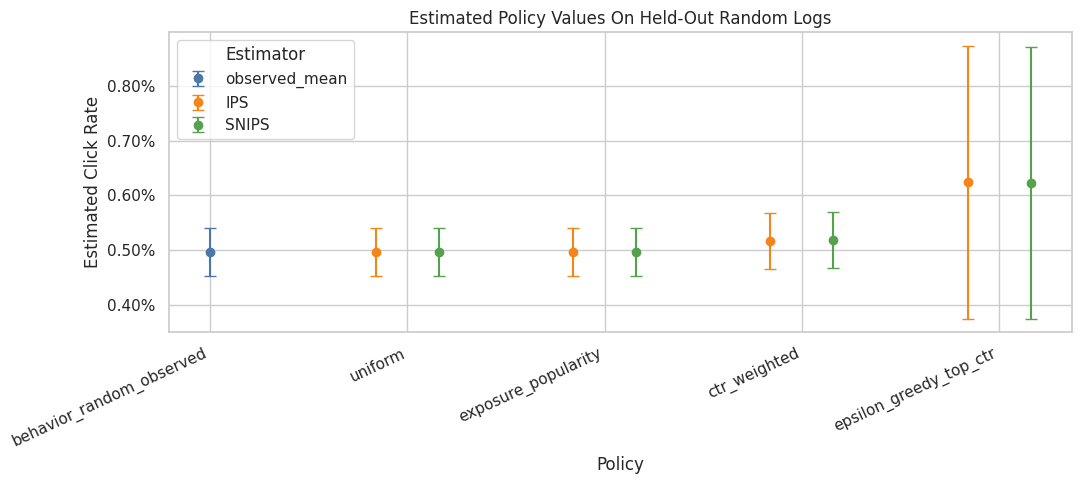

In [17]:
# Plot IPS and SNIPS policy value estimates.
plot_estimates = estimate_comparison.copy()
plot_estimates["lower_error"] = plot_estimates["estimate"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["estimate"]

policy_order = plot_estimates["policy"].unique()
estimator_order = ["observed_mean", "IPS", "SNIPS"]
colors = {
    "observed_mean": "#4C78A8",
    "IPS": "#F58518",
    "SNIPS": "#54A24B",
}
offsets = {
    "observed_mean": 0.0,
    "IPS": -0.16,
    "SNIPS": 0.16,
}

fig, ax = plt.subplots(figsize=(11, 5))

for estimator in estimator_order:
    subset = plot_estimates[plot_estimates["estimator"] == estimator]

    for _, row in subset.iterrows():
        x_base = list(policy_order).index(row["policy"])
        x = x_base + offsets[estimator]

        ax.errorbar(
            x=x,
            y=row["estimate"],
            yerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="o",
            color=colors[estimator],
            ecolor=colors[estimator],
            capsize=4,
            linewidth=1.5,
            markersize=6,
            label=estimator if row["policy"] == subset["policy"].iloc[0] else None,
        )

ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=25, ha="right")
ax.set_title("Estimated Policy Values On Held-Out Random Logs")
ax.set_xlabel("Policy")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
ax.legend(title="Estimator")
plt.tight_layout()
plt.show()


The IPS and SNIPS estimates are the first direct counterfactual policy values. IPS is unbiased under correct propensities but can be high variance; SNIPS normalizes weights to trade some bias for stability.


### Weight Diagnostics by Policy

This cell summarizes the importance weights for each candidate policy. The estimate is only as credible as the weights are stable.

The most important fields are:

- `mean_weight`: should be near 1 when the evaluation policy is well supported
- `max_weight`: flags extreme individual rows
- `ess_share`: effective sample size as a fraction of rows

Low ESS means the estimate is being driven by a smaller effective number of observations.


In [18]:
weight_diagnostics = estimate_results[
    ["policy", "mean_weight", "max_weight", "p99_weight", "ess", "ess_share"]
].sort_values("ess_share")

weight_diagnostics


,policy,mean_weight,max_weight,p99_weight,ess,ess_share
3,epsilon_greedy_top_ctr,1.001105,29.050000,29.050000,4029.027734,0.040290
2,ctr_weighted,0.996987,2.740842,2.740842,79062.817039,0.790628
1,exposure_popularity,1.000591,1.132200,1.132200,99639.920774,0.996399
0,uniform,1.000000,1.000000,1.000000,100000.000000,1.000000


The weight diagnostics show whether each policy value estimate is supported by enough logged data. Policies with large weights or low ESS may look attractive but carry higher offline evaluation risk.


#### Plot Weight Risk With Percentiles And ESS

The overlapping histogram was hard to read, so this plot switches to two simpler diagnostics.

The left panel shows selected weight percentiles for each policy, which reveals how large the typical and tail weights get. The right panel shows effective sample size share, which tells us how much of the held-out log is effectively being used after weighting.

This view is clearer for OPE because the exact shape of the full weight distribution matters less than the tail size and the amount of usable support. High p99 or max weights plus low ESS are the warning signs.


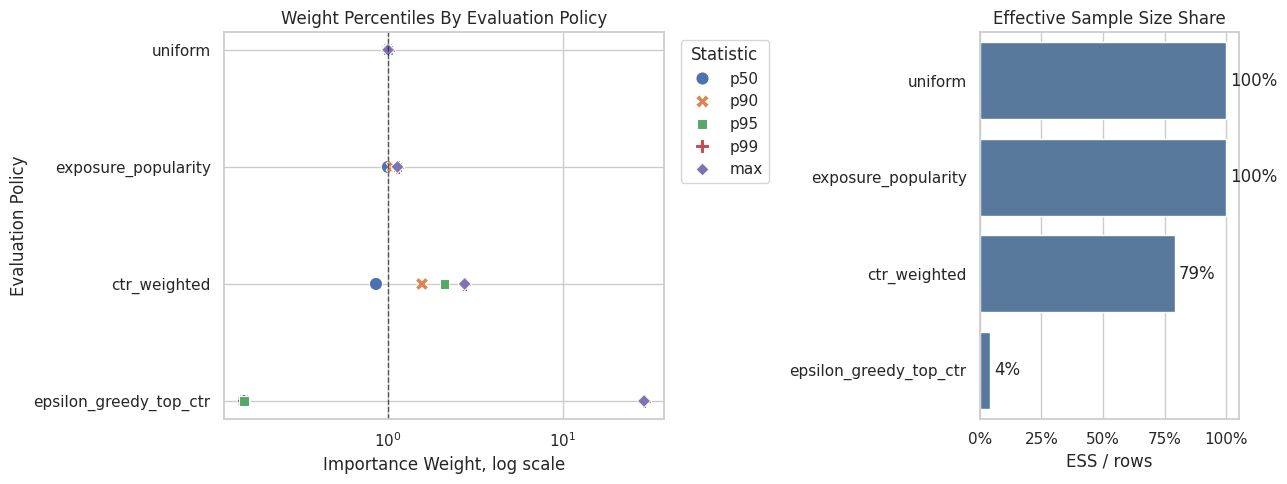

,policy,p50,p90,p95,p99,max,ess_share
0,uniform,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,exposure_popularity,0.998580,1.062500,1.130160,1.132200,1.132200,0.996399
2,ctr_weighted,0.852995,1.563756,2.103486,2.740842,2.740842,0.790628
3,epsilon_greedy_top_ctr,0.150000,0.150000,0.150000,29.050000,29.050000,0.040290


In [19]:
# Plot weight risk with percentiles and ESS.
weight_summary_rows = []
for policy in policy_cols:
    weights = eval_scored[f"w_{policy}"].to_numpy()
    weight_summary_rows.append(
        {
            "policy": policy,
            "p50": np.percentile(weights, 50),
            "p90": np.percentile(weights, 90),
            "p95": np.percentile(weights, 95),
            "p99": np.percentile(weights, 99),
            "max": weights.max(),
            "ess_share": effective_sample_size(weights) / len(weights),
        }
    )

weight_summary_plot = pd.DataFrame(weight_summary_rows).sort_values("ess_share", ascending=False)
percentile_plot_df = weight_summary_plot.melt(
    id_vars="policy",
    value_vars=["p50", "p90", "p95", "p99", "max"],
    var_name="weight_stat",
    value_name="weight",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.7, 1]})

sns.scatterplot(
    data=percentile_plot_df,
    x="weight",
    y="policy",
    hue="weight_stat",
    style="weight_stat",
    s=90,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Weight Percentiles By Evaluation Policy")
axes[0].set_xlabel("Importance Weight, log scale")
axes[0].set_ylabel("Evaluation Policy")
axes[0].axvline(1, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0].legend(title="Statistic", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=weight_summary_plot,
    x="ess_share",
    y="policy",
    ax=axes[1],
    color="#4C78A8",
)
axes[1].set_title("Effective Sample Size Share")
axes[1].set_xlabel("ESS / rows")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[1].set_xlim(0, 1.05)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f"{x:.0%}", padding=3)

plt.tight_layout()
plt.show()

weight_summary_plot


The weight diagnostics show whether each policy value estimate is supported by enough logged data. Policies with large weights or low ESS may look attractive but carry higher offline evaluation risk.


#### Compare IPS And SNIPS Directly

This cell computes the difference between IPS and SNIPS for each policy. When mean weights are close to 1 and the sample is large, IPS and SNIPS should often be similar.

Large gaps between IPS and SNIPS are warning signs. They can indicate weight instability, finite-sample noise, or a policy that is poorly matched to the behavior logs.


In [20]:
ips_snips_gap = estimate_results.assign(
    snips_minus_ips=lambda x: x["snips"] - x["ips"],
    relative_gap_pct=lambda x: 100 * (x["snips"] - x["ips"]) / x["ips"],
)[["policy", "ips", "snips", "snips_minus_ips", "relative_gap_pct", "mean_weight", "ess_share"]]

ips_snips_gap


,policy,ips,snips,snips_minus_ips,relative_gap_pct,mean_weight,ess_share
0,uniform,0.004980,0.004980,-0.000000,-0.000000,1.000000,1.000000
1,exposure_popularity,0.004971,0.004968,-0.000003,-0.059031,1.000591,0.996399
2,ctr_weighted,0.005172,0.005188,0.000016,0.302162,0.996987,0.790628
3,epsilon_greedy_top_ctr,0.006238,0.006231,-0.000007,-0.110378,1.001105,0.040290


The IPS-SNIPS gap is a stability diagnostic. Large gaps suggest that weight normalization materially changes the estimate, which usually means the policy has support or variance concerns.


### Weight Clipping Sensitivity

Weight clipping caps large weights before estimating policy value. Clipping can reduce variance, but it introduces bias because it changes the estimator.

This cell evaluates several clipping thresholds. A stable policy should remain similar when weights are clipped. A sensitive policy deserves caution in the interpretation.


In [21]:
clip_values = [None, 5, 10, 20]
clipping_rows = []
for policy in policy_cols:
    for clip in clip_values:
        clipping_rows.append(
            estimate_ips_snips(
                reward=eval_scored["click"],
                weight=eval_scored[f"w_{policy}"],
                policy_name=policy,
                clip=clip,
            )
        )

clipping_sensitivity = pd.DataFrame(clipping_rows)
clipping_sensitivity[["policy", "clip", "ips", "snips", "mean_weight", "max_weight", "ess_share"]]


,policy,clip,ips,snips,mean_weight,max_weight,ess_share
0,uniform,none,0.004980,0.004980,1.000000,1.000000,1.000000
1,uniform,5,0.004980,0.004980,1.000000,1.000000,1.000000
2,uniform,10,0.004980,0.004980,1.000000,1.000000,1.000000
3,uniform,20,0.004980,0.004980,1.000000,1.000000,1.000000
4,exposure_popularity,none,0.004971,0.004968,1.000591,1.132200,0.996399
5,exposure_popularity,5,0.004971,0.004968,1.000591,1.132200,0.996399
6,exposure_popularity,10,0.004971,0.004968,1.000591,1.132200,0.996399
7,exposure_popularity,20,0.004971,0.004968,1.000591,1.132200,0.996399
8,ctr_weighted,none,0.005172,0.005188,0.996987,2.740842,0.790628
9,ctr_weighted,5,0.005172,0.005188,0.996987,2.740842,0.790628


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Plot Clipping Sensitivity

This plot shows how IPS and SNIPS estimates move as the clipping threshold changes. The unclipped estimate is labeled `none`.

If a policy estimate changes sharply after clipping, then a few large-weight rows were materially influencing the estimate. That should be discussed as a limitation.


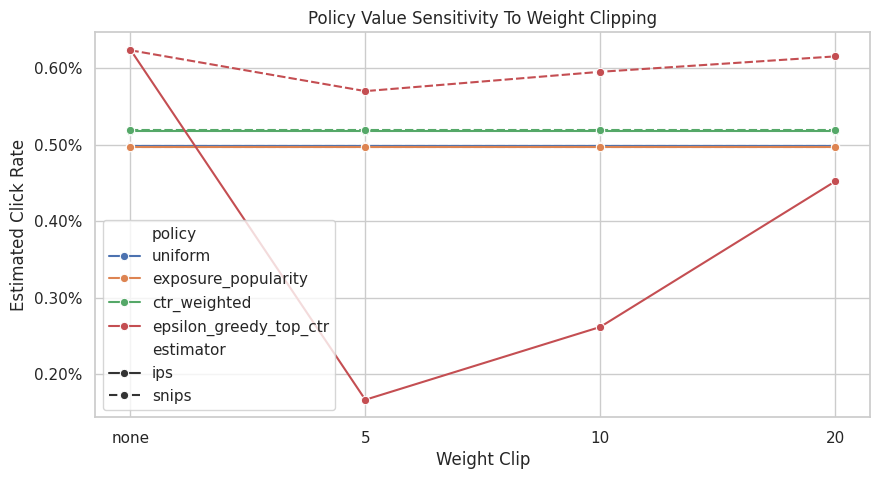

In [22]:
clipping_plot_df = clipping_sensitivity.melt(
    id_vars=["policy", "clip"],
    value_vars=["ips", "snips"],
    var_name="estimator",
    value_name="estimate",
)
clipping_plot_df["clip_label"] = clipping_plot_df["clip"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=clipping_plot_df,
    x="clip_label",
    y="estimate",
    hue="policy",
    style="estimator",
    marker="o",
    ax=ax,
)
ax.set_title("Policy Value Sensitivity To Weight Clipping")
ax.set_xlabel("Weight Clip")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


### Estimated Lift Relative to Random Behavior

This cell converts estimates into lift over the observed random-policy baseline.

Lift is easier to discuss with product stakeholders because it answers: how much higher or lower is the estimated click rate relative to the current logged policy? Here lift is expressed in both percentage points and relative percent.


In [23]:
lift_table = estimate_comparison.query("estimator != 'observed_mean'").copy()
lift_table["baseline_click_rate"] = behavior_value
lift_table["lift_pp"] = 100 * (lift_table["estimate"] - behavior_value)
lift_table["relative_lift_pct"] = 100 * (lift_table["estimate"] / behavior_value - 1)

lift_table[["policy", "estimator", "estimate", "baseline_click_rate", "lift_pp", "relative_lift_pct", "ess_share"]].sort_values(
    "estimate", ascending=False
)


,policy,estimator,estimate,baseline_click_rate,lift_pp,relative_lift_pct,ess_share
7,epsilon_greedy_top_ctr,IPS,0.006238,0.004980,0.125800,25.261044,0.040290
8,epsilon_greedy_top_ctr,SNIPS,0.006231,0.004980,0.125111,25.122784,0.040290
6,ctr_weighted,SNIPS,0.005188,0.004980,0.020806,4.178004,0.790628
5,ctr_weighted,IPS,0.005172,0.004980,0.019244,3.864167,0.790628
1,uniform,IPS,0.004980,0.004980,0.000000,0.000000,1.000000
2,uniform,SNIPS,0.004980,0.004980,0.000000,0.000000,1.000000
3,exposure_popularity,IPS,0.004971,0.004980,-0.000904,-0.181598,0.996399
4,exposure_popularity,SNIPS,0.004968,0.004980,-0.001198,-0.240522,0.996399


The lift table translates policy values into improvement over the random logging baseline. This framing is easier to communicate, but it should always be read alongside uncertainty and weight diagnostics.


### Optional BTS Log Comparison

Notebook 2 showed that BTS has more variable propensities than random logging. This section evaluates the same candidate policies on a held-out BTS split to show how logging-policy choice affects estimator stability.

This is a diagnostic comparison for how adaptive logging changes weight behavior. Random and BTS logs may cover different traffic patterns. The point is to see how adaptive logging changes weight behavior.


In [24]:
if not BTS_SAMPLE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {BTS_SAMPLE_PATH}. Run 02_behavior_policy_and_propensities.ipynb first to create the BTS cache."
    )

bts_df = pd.read_parquet(BTS_SAMPLE_PATH).sort_values("timestamp").reset_index(drop=True)
bts_eval_df = bts_df.iloc[int(len(bts_df) * SPLIT_FRACTION) :].copy()

bts_scored = bts_eval_df[["timestamp", "item_id", "position", "click", "propensity_score"]].copy()
for policy in policy_cols:
    probability_map = policy_probability_df.set_index("item_id")[policy]
    bts_scored[f"pi_e_{policy}"] = bts_scored["item_id"].map(probability_map)
    bts_scored[f"w_{policy}"] = bts_scored[f"pi_e_{policy}"] / bts_scored["propensity_score"]

bts_scored[["timestamp", "item_id", "position", "click", "propensity_score", "w_uniform"]].head()


,timestamp,item_id,position,click,propensity_score,w_uniform
100000,2019-11-24 03:28:23.210755+00:00,10,3,0,0.022395,1.313318
100001,2019-11-24 03:28:23.233904+00:00,19,2,0,0.011710,2.511679
100002,2019-11-24 03:28:23.234656+00:00,1,3,0,0.025370,1.159313
100003,2019-11-24 03:28:23.234692+00:00,13,1,0,0.410980,0.071565
100004,2019-11-24 03:28:23.370371+00:00,1,3,0,0.025370,1.159313


The BTS comparison illustrates how a more adaptive logging policy can change support and estimator stability. This is a useful contrast because production logs often look more like BTS than a clean randomized policy.


#### Estimate The Same Policies From BTS Logs

This cell computes IPS and SNIPS estimates using the BTS held-out rows. The evaluation policies are the same policies learned from the random-policy training split.

Comparing the random-log estimates and BTS-log estimates helps illustrate an important OPE lesson. The estimator depends on the target policy and on how well the behavior logs support that target policy.


In [25]:
bts_results = []
for policy in policy_cols:
    bts_results.append(
        estimate_ips_snips(
            reward=bts_scored["click"],
            weight=bts_scored[f"w_{policy}"],
            policy_name=policy,
        )
    )

bts_estimate_results = pd.DataFrame(bts_results).assign(log_source="bts")
random_estimate_results = estimate_results.assign(log_source="random")

log_source_comparison = pd.concat([random_estimate_results, bts_estimate_results], ignore_index=True)
log_source_comparison[["log_source", "policy", "ips", "snips", "mean_weight", "max_weight", "ess_share"]]


,log_source,policy,ips,snips,mean_weight,max_weight,ess_share
0,random,uniform,0.004980,0.004980,1.000000,1.000000,1.000000
1,random,exposure_popularity,0.004971,0.004968,1.000591,1.132200,0.996399
2,random,ctr_weighted,0.005172,0.005188,0.996987,2.740842,0.790628
3,random,epsilon_greedy_top_ctr,0.006238,0.006231,1.001105,29.050000,0.040290
4,bts,uniform,0.004483,0.004779,0.937988,125.156446,0.098302
5,bts,exposure_popularity,0.004458,0.004736,0.941207,123.489362,0.095822
6,bts,ctr_weighted,0.004490,0.004752,0.944894,157.810018,0.098642
7,bts,epsilon_greedy_top_ctr,0.006092,0.006408,0.950666,69.492620,0.036405


The BTS comparison illustrates how a more adaptive logging policy can change support and estimator stability. This is a useful contrast because production logs often look more like BTS than a clean randomized policy.


#### Plot ESS By Log Source

This plot compares effective sample size shares across random and BTS logs for the same evaluation policies.

When ESS is lower, the estimate effectively relies on fewer observations. This is often the clearest visual explanation of why randomized exploration data is so valuable for off-policy evaluation.


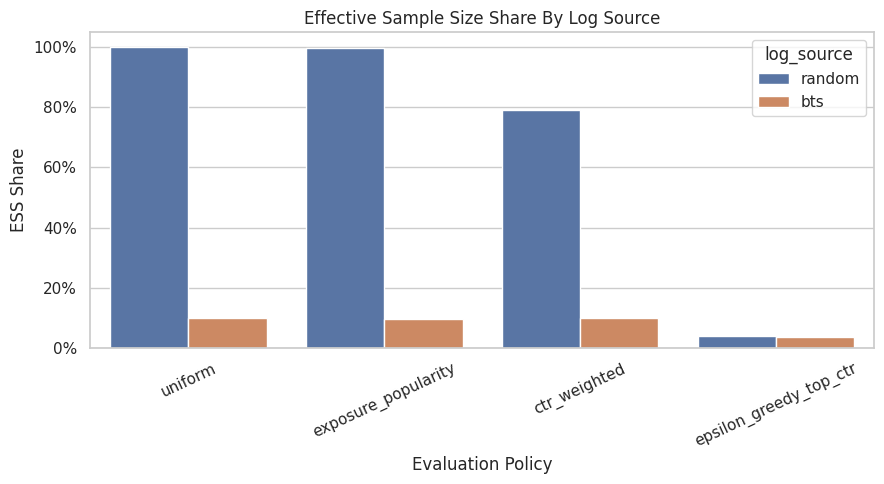

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=log_source_comparison, x="policy", y="ess_share", hue="log_source", ax=ax)
ax.set_title("Effective Sample Size Share By Log Source")
ax.set_xlabel("Evaluation Policy")
ax.set_ylabel("ESS Share")
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()


The weight diagnostics show whether each policy value estimate is supported by enough logged data. Policies with large weights or low ESS may look attractive but carry higher offline evaluation risk.


#### Main Results Table

This cell creates a compact final table for Notebook 3. It includes the random-log estimates, confidence intervals, weight diagnostics, and estimated lift over the observed random behavior baseline.

This table summarizes what IPS and SNIPS can support before moving to doubly robust estimation.


In [27]:
final_results = lift_table.merge(
    weight_diagnostics,
    on="policy",
    how="left",
    suffixes=("", "_diagnostic"),
)
final_results = final_results[
    [
        "policy",
        "estimator",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "mean_weight",
        "max_weight",
        "p99_weight",
        "ess_share",
    ]
].sort_values(["estimate", "ess_share"], ascending=[False, False])

final_results


,policy,estimator,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,mean_weight,max_weight,p99_weight,ess_share
6,epsilon_greedy_top_ctr,IPS,0.006238,0.003756,0.008720,0.125800,25.261044,1.001105,29.050000,29.050000,0.040290
7,epsilon_greedy_top_ctr,SNIPS,0.006231,0.003759,0.008703,0.125111,25.122784,1.001105,29.050000,29.050000,0.040290
5,ctr_weighted,SNIPS,0.005188,0.004675,0.005701,0.020806,4.178004,0.996987,2.740842,2.740842,0.790628
4,ctr_weighted,IPS,0.005172,0.004660,0.005685,0.019244,3.864167,0.996987,2.740842,2.740842,0.790628
0,uniform,IPS,0.004980,0.004544,0.005416,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
1,uniform,SNIPS,0.004980,0.004544,0.005416,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
2,exposure_popularity,IPS,0.004971,0.004535,0.005407,-0.000904,-0.181598,1.000591,1.132200,1.132200,0.996399
3,exposure_popularity,SNIPS,0.004968,0.004532,0.005404,-0.001198,-0.240522,1.000591,1.132200,1.132200,0.996399


The reshaped table puts policy values, uncertainty, and diagnostics into a comparison-friendly format. This is the table that later plots and recommendation decisions build from. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


## Takeaways and Next Step

This notebook introduced the first actual off-policy estimators in the project.

The most important lessons are:

- IPS estimates policy value by reweighting rewards with `pi_e / pi_b`.
- SNIPS uses the same weights but normalizes by the total weight, often improving stability.
- Weight diagnostics are essential; they are part of the estimate.
- Randomized logging makes simple OPE much cleaner because the behavior policy explores broadly.
- Concentrated policies can have attractive point estimates but lower effective sample size.
- BTS logs are useful, but their adaptive propensities make weight behavior more delicate.

The next notebook should introduce **doubly robust OPE**, which combines importance weighting with a reward model. That will help reduce variance while preserving some protection against model misspecification.
